In [4]:
!pip install pandas
!pip install matplotlib

  Using cached matplotlib-3.10.8-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (9.8 MB)
Using cached contourpy-1.3.3-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (363 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 24.9 MB/s  0:00:00 24.4 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 55.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 57.6 MB/s  0:00:00
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib] 6/7 [matplotlib]ow]


In [6]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import json
from pathlib import Path

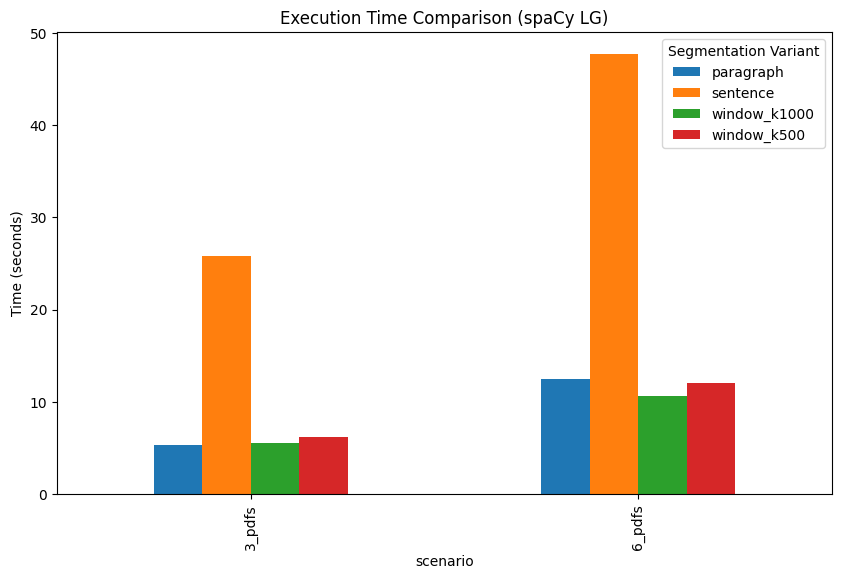

In [7]:
# Load the performance report
with open("../performance_report.json", "r", encoding="utf-8") as f:
    perf_data = json.load(f)

df_perf = pd.DataFrame(perf_data)

# Simple plot to compare total time per variant
df_perf.pivot(index='scenario', columns='variant', values='total_time_sec').plot(kind='bar', figsize=(10, 6))
plt.title("Execution Time Comparison (spaCy LG)")
plt.ylabel("Time (seconds)")
plt.legend(title="Segmentation Variant")
plt.show()

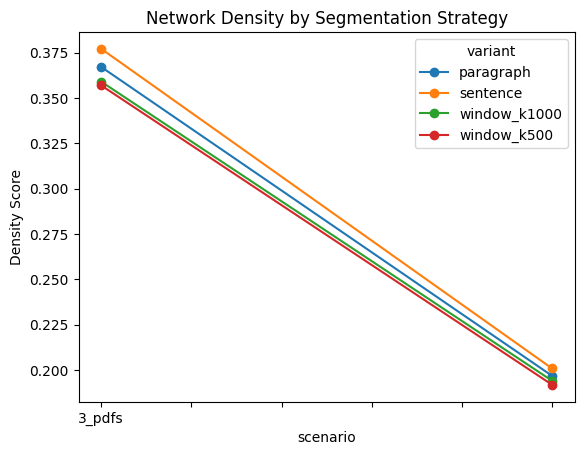

In [8]:
# Load graph metrics
with open("../graph_metrics_report.json", "r", encoding="utf-8") as f:
    metrics_data = json.load(f)

df_metrics = pd.DataFrame(metrics_data)

# Plotting Density to see how "connected" the graph is per variant
df_metrics.pivot(index='scenario', columns='variant', values='density').plot(kind='line', marker='o')
plt.title("Network Density by Segmentation Strategy")
plt.ylabel("Density Score")
plt.show()

In [9]:
# Load one of your GML graphs
graph_path = Path("../data/graphs/graph_6_pdfs_sentence.gml")
G = nx.read_gml(graph_path)

# Calculate centrality
centrality = nx.degree_centrality(G)
top_nodes = sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top 10 Entities by Degree Centrality:")
for node, val in top_nodes:
    print(f"{node}: {val:.4f}")

Top 10 Entities by Degree Centrality:
UFRN: 0.9635
Natal: 0.9635
Prof: 0.9635
Universidade Federal do Rio Grande do Norte: 0.9635
Figura: 0.9635
RESULTADOS: 0.8752
Sistema de Bibliotecas: 0.8738
SISBI: 0.8738
Catalogação de Publicação na Fonte: 0.8738
Python: 0.8397
